# Knowledge Graph Inspector

## About this dummy KG

`Patent_dummy_KG.graphml` is a minimal example knowledge graph built from a single dummy document:

> `MARS_Data/MDs_paper/Patents/dummy_example_material_specification_sheet.md`

It was generated using `KG_Generation/build_kg.py` with `llama-3.3-70B-Instruct ` as the LLM and `nomic-ai/nomic-embed-text-v1.5` for node embeddings. This mirrors the process used to build the three real knowledge graphs in the MARS paper (PFAS, MatProp, Patents), which were produced with a similar pipeline and a much larger corpus of documents. The open-source version of that pipeline is in `KG_Generation/`, adapted from `make_KG_PFAS.ipynb` in GraphAgents, LAMM-MIT.

The dummy KG is included so the full MARS pipeline can be run end-to-end out of the box. Replace `dummy_example_material_specification_sheet.md` with real documents and re-run `build_kg.py` to build a domain-specific graph.

---

This notebook loads the graph, prints a summary, samples example paths, and renders a layout visualisation.

In [1]:
from pathlib import Path
from collections import Counter

import yaml
import networkx as nx
import matplotlib.pyplot as plt

## Configuration

Set `GRAPH_FILE` to point at your `.graphml`, or leave it as `None` to read the path from `config.yaml`.

In [2]:
GRAPH_FILE  = None          # e.g. "../MARS_Data/KGs/Patent_dummy_KG.graphml", or None to use config.yaml
CONFIG_FILE = "config.yaml"
MAX_LABELS  = 40            # draw node labels only when the graph has <= this many nodes; 0 to disable
PLOT_SEED   = 42

## Load graph

In [3]:
if GRAPH_FILE:
    graph_path = Path(GRAPH_FILE).resolve()
else:
    with open(CONFIG_FILE) as f:
        cfg = yaml.safe_load(f)
    paths = cfg["paths"]
    out   = Path(paths["output_dir"])
    if not out.is_absolute():
        out = (Path(CONFIG_FILE).resolve().parent / out).resolve()
    graph_path = (out / paths["graph_output_file"]).resolve()

print(f"Loading: {graph_path}")
G = nx.read_graphml(graph_path)
print("Done.")

Loading: /Users/tarjeihage/Downloads/MARS_Data_Paper/MARS_Data/KGs/Patent_dummy_KG.graphml
Done.


## Summary

In [4]:
ud   = nx.Graph(G) if G.is_directed() else G
n_cc = nx.number_connected_components(ud)

print(f"Nodes:             {G.number_of_nodes()}")
print(f"Edges:             {G.number_of_edges()}")
print(f"Directed:          {G.is_directed()}")
print(f"Conn. components:  {n_cc}")

types = Counter(str(d["type"]) for _, d in G.nodes(data=True) if "type" in d)
if types:
    print("\nNode types:")
    for t, c in types.most_common():
        print(f"  {c:6d}  {t}")

rels = Counter(str(d["relation"]) for _, _, d in G.edges(data=True) if "relation" in d)
if rels:
    top = min(15, len(rels))
    print(f"\nTop edge relations (up to {top}):")
    for r, c in rels.most_common(top):
        print(f"  {c:6d}  {r}")

Nodes:             26
Edges:             25
Directed:          True
Conn. components:  1

Node types:
       9  Physical Property
       7  Industry
       5  Property
       1  Material
       1  Chemical Name
       1  Supplier
       1  Material Description
       1  Standard

Top edge relations (up to 7):
       9  has physical property
       7  used in industry
       5  has property
       1  is also known as
       1  supplied by
       1  is a type of
       1  meets standard


## Graph visualisation

## Example paths

In [5]:
import random

N_PATHS         = 10   # number of paths to print
MIN_PATH_LENGTH = 2    # minimum hops (edges)
MAX_PATH_LENGTH = 4    # maximum hops (edges)
PATH_SEED       = 42

random.seed(PATH_SEED)
ug    = nx.Graph(G)    # undirected for path-finding
nodes = list(ug.nodes())

def format_path(graph, node_path):
    parts = [f"({node_path[0]})"]
    for a, b in zip(node_path, node_path[1:]):
        data = graph.get_edge_data(a, b) or graph.get_edge_data(b, a) or {}
        rel  = data.get("relation", "—")
        parts.append(f"-[{rel}]-({b})")
    return "".join(parts)

printed  = 0
attempts = 0
while printed < N_PATHS and attempts < 5000:
    attempts += 1
    src, dst = random.sample(nodes, 2)
    try:
        path = nx.shortest_path(ug, src, dst)
    except nx.NetworkXNoPath:
        continue
    hops = len(path) - 1
    if MIN_PATH_LENGTH <= hops <= MAX_PATH_LENGTH:
        print(format_path(G, path))
        printed += 1

if printed == 0:
    print("No paths found in the requested length range — try adjusting MIN/MAX_PATH_LENGTH.")

(Tensile modulus)-[has physical property]-(PEEK)-[is a type of]-(High-performance engineering thermoplastic)
(Aerospace)-[used in industry]-(PEEK)-[used in industry]-(Medical)
(Medical)-[used in industry]-(PEEK)-[used in industry]-(Automotive)
(Melting temperature)-[has physical property]-(PEEK)-[is a type of]-(High-performance engineering thermoplastic)
(Flexural strength)-[has physical property]-(PEEK)-[has physical property]-(Melting temperature)
(Density)-[has physical property]-(PEEK)-[supplied by]-(Plastics Supplier Company)
(Water absorption, 24 h)-[has physical property]-(PEEK)-[has property]-(Wear and abrasion resistance)
(Plastics Supplier Company)-[supplied by]-(PEEK)-[used in industry]-(Electronics)
(Medical)-[used in industry]-(PEEK)-[meets standard]-(UL94 V-0 flammability rating)
(Density)-[has physical property]-(PEEK)-[used in industry]-(Electronics)


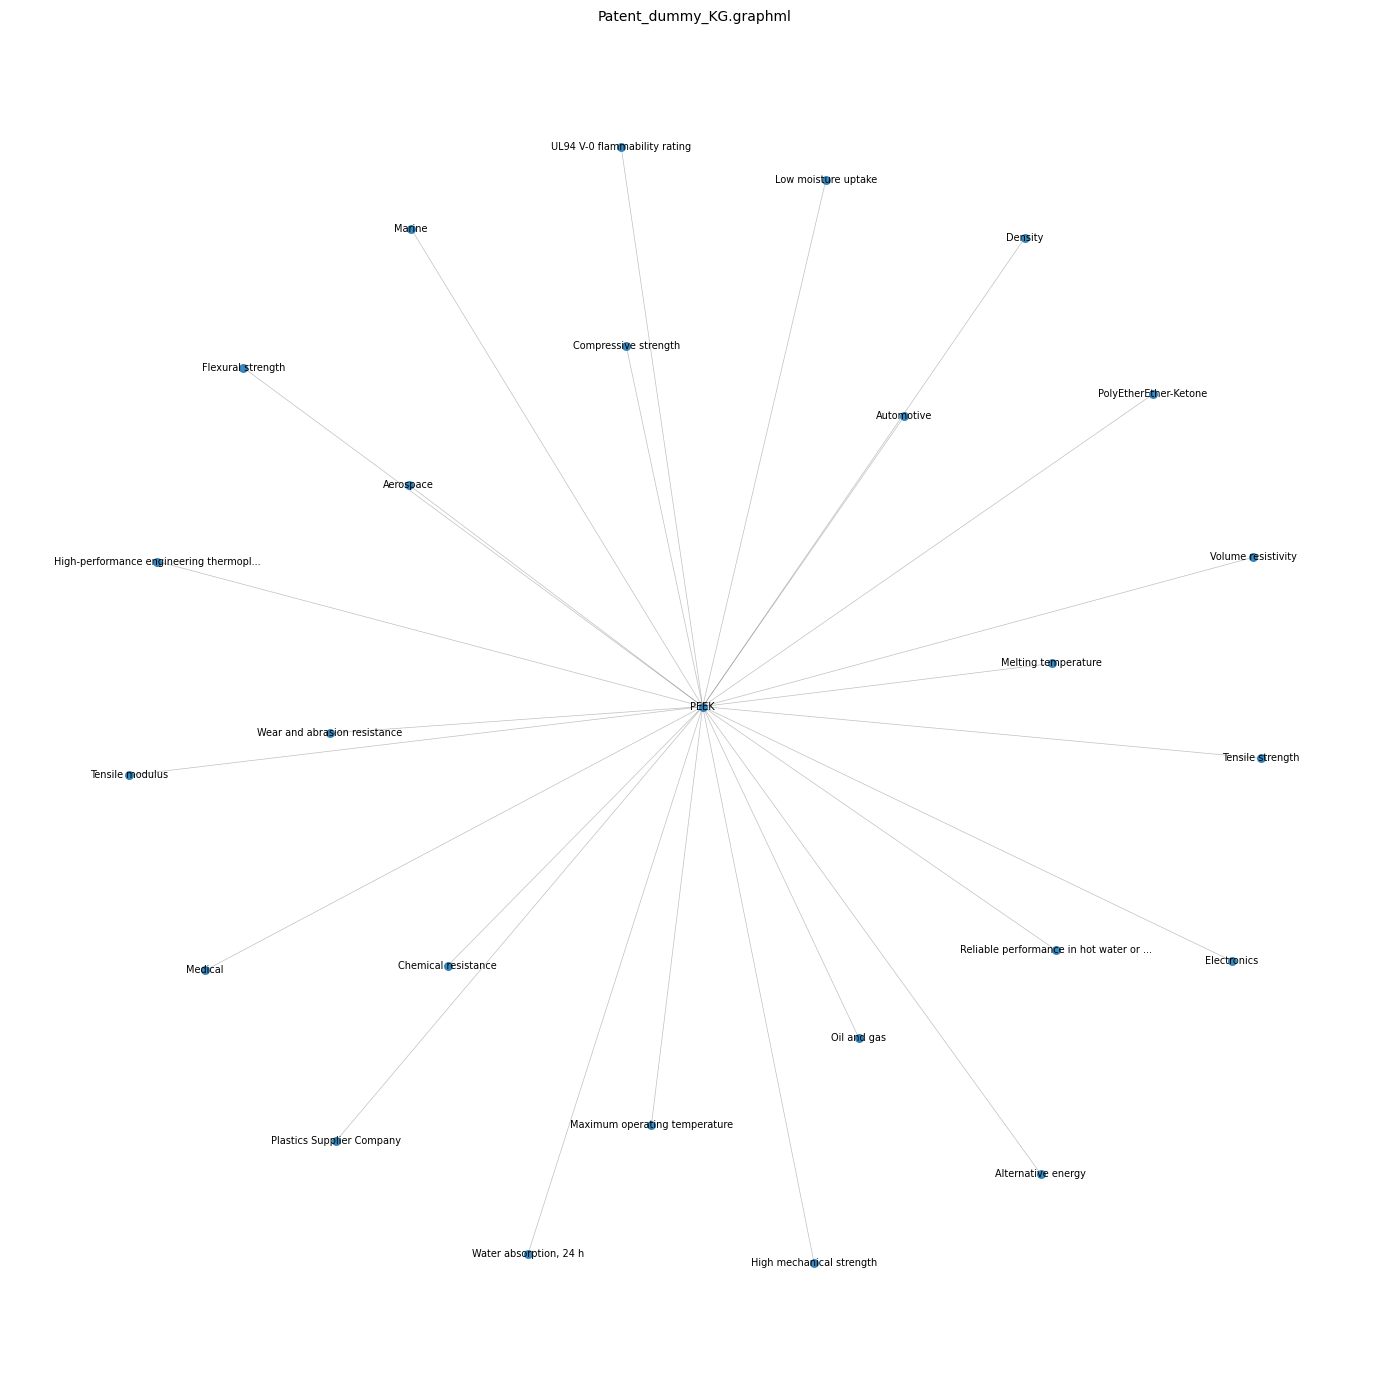

In [6]:
gg  = nx.Graph(G)
pos = nx.spring_layout(gg, seed=PLOT_SEED, k=2 / max(1, gg.number_of_nodes() ** 0.5))

fig, ax = plt.subplots(figsize=(14, 14))
nx.draw_networkx_edges(gg, pos, ax=ax, alpha=0.25, width=0.5)
nx.draw_networkx_nodes(gg, pos, ax=ax, node_size=30, alpha=0.85)

if MAX_LABELS > 0 and gg.number_of_nodes() <= MAX_LABELS:
    labels = {n: n if len(n) <= 40 else n[:37] + "..." for n in gg.nodes()}
    nx.draw_networkx_labels(gg, pos, labels, ax=ax, font_size=7)

ax.set_title(graph_path.name, fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()